In [1]:
from PIL import Image
import requests
from transformers import AutoProcessor, Kosmos2ForConditionalGeneration

model = Kosmos2ForConditionalGeneration.from_pretrained("microsoft/kosmos-2-patch14-224")
processor = AutoProcessor.from_pretrained("microsoft/kosmos-2-patch14-224")

url = "https://huggingface.co/microsoft/kosmos-2-patch14-224/resolve/main/snowman.jpg"
image = Image.open(requests.get(url, stream=True).raw)

prompt = "<grounding> An image of"

inputs = processor(text=prompt, images=image, return_tensors="pt")

generated_ids = model.generate(
    pixel_values=inputs["pixel_values"],
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    image_embeds=None,
    image_embeds_position_mask=inputs["image_embeds_position_mask"],
    use_cache=True,
    max_new_tokens=64,
)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
processed_text = processor.post_process_generation(generated_text, cleanup_and_extract=False)
processed_text

caption, entities = processor.post_process_generation(generated_text)
caption

entities


/home/ubuntu/miniconda3/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[('a snowman', (12, 21), [(0.390625, 0.046875, 0.984375, 0.828125)]),
 ('a fire', (41, 47), [(0.171875, 0.015625, 0.484375, 0.890625)])]

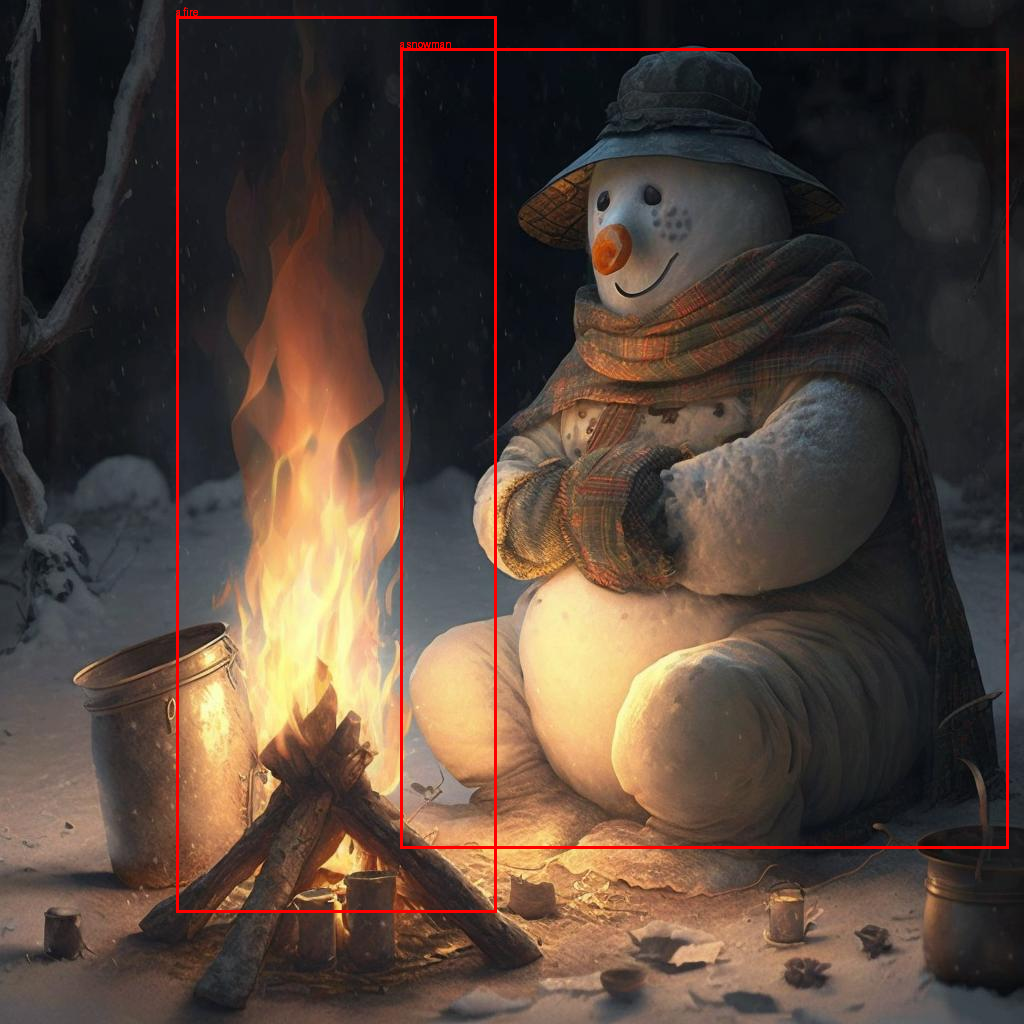

In [4]:
from PIL import ImageDraw

# Draw the regions on the image
draw = ImageDraw.Draw(image)

# Iterate over entities to draw bounding boxes
for entity in entities:
    label = entity[0]  # Extract the label (e.g., "a snowman")
    bbox = entity[2][0]  # Extract the bounding box
    left = bbox[0] * image.width
    top = bbox[1] * image.height
    right = bbox[2] * image.width
    bottom = bbox[3] * image.height

    # Draw the rectangle
    draw.rectangle([left, top, right, bottom], outline="red", width=3)

    # Add the label above the bounding box
    draw.text((left, top - 10), label, fill="red")

# Show the image with bounding boxes and also smaller
image.show()

# Optionally save the image with bounding boxes
image.save("output_with_regions.jpg")